In [11]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from urllib.request import urlretrieve

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42

def train_and_evaluate_mlp(
    Xtrain, Xtest, ytrain, ytest, target_names, title, hidden_layer_sizes=(64, 32), max_iter=200
):
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        max_iter=max_iter,
        random_state=RANDOM_STATE,
        early_stopping=True,
        n_iter_no_change=10,
        validation_fraction=0.1,
        learning_rate_init=1e-3,
    )
    mlp.fit(Xtrain, ytrain)

    y_pred = mlp.predict(Xtest)
    print(f"=== {title} ===")
    print(f"Acuracia: {accuracy_score(ytest, y_pred):.4f}")
    print(classification_report(ytest, y_pred, target_names=target_names))

    ConfusionMatrixDisplay.from_estimator(
        mlp,
        Xtest,
        ytest,
        display_labels=target_names,
        xticks_rotation=45,
    )
    plt.title(f"Matriz de Confusao - {title}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(mlp.loss_curve_)
    plt.title(f"Convergencia (Loss) - {title}")
    plt.xlabel("Epocas")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.show()

    return mlp, y_pred

In [12]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

=== Iris ===
Acuracia: 0.9474
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



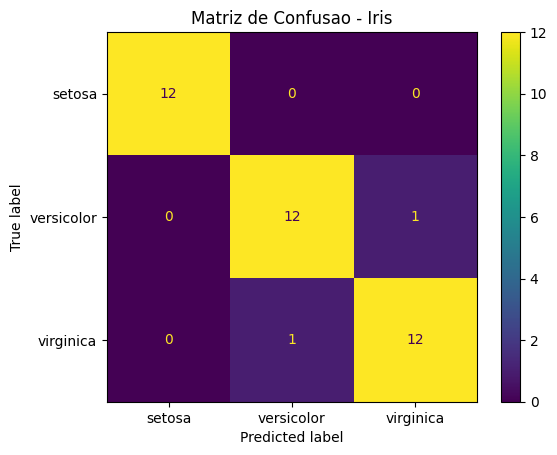

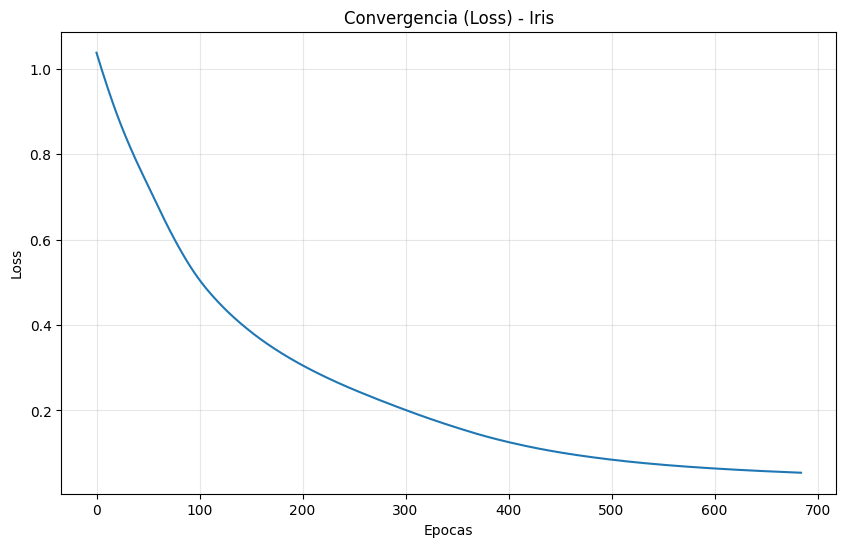

In [13]:
# Desafio 1: Iris
iris_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                solver="adam",
                alpha=1e-4,
                learning_rate_init=3e-4,
                max_iter=2000,
                random_state=7,
            ),
        ),
    ]
)
iris_pipeline.fit(Xtrain, ytrain)

y_pred = iris_pipeline.predict(Xtest)
print("=== Iris ===")
print(f"Acuracia: {accuracy_score(ytest, y_pred):.4f}")
print(classification_report(ytest, y_pred, target_names=target_names))

ConfusionMatrixDisplay.from_estimator(
    iris_pipeline, Xtest, ytest, display_labels=target_names
 )
plt.title("Matriz de Confusao - Iris")
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(iris_pipeline.named_steps["mlp"].loss_curve_)
plt.title("Convergencia (Loss) - Iris")
plt.xlabel("Epocas")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

=== MNIST ===
Acuracia: 0.9643
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       394
           1       0.97      0.98      0.98       450
           2       0.98      0.96      0.97       399
           3       0.97      0.96      0.97       408
           4       0.94      0.97      0.96       390
           5       0.97      0.95      0.96       361
           6       0.96      0.98      0.97       393
           7       0.97      0.97      0.97       417
           8       0.96      0.95      0.96       390
           9       0.94      0.95      0.94       398

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



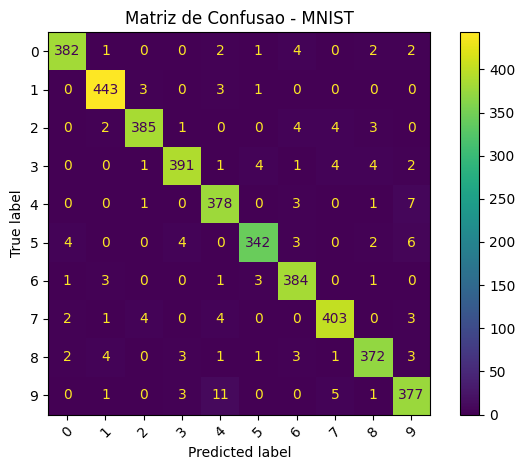

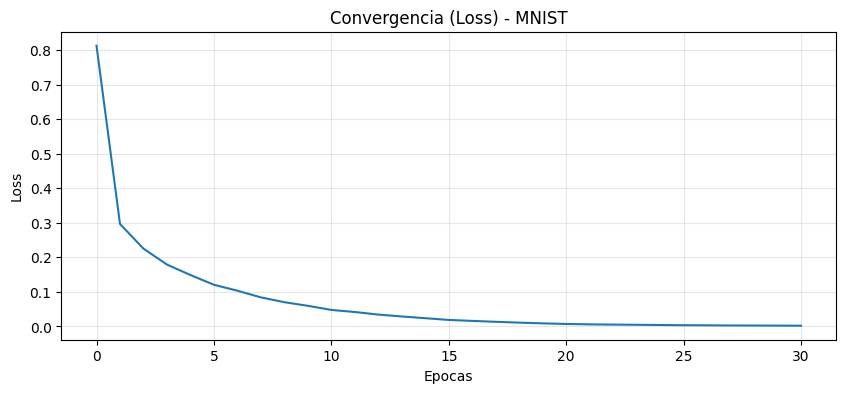

In [14]:
# Desafio 2: MNIST
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_mnist, y_mnist = mnist.data, mnist.target.astype(int)
X_mnist = X_mnist / 255.0  # normalizacao

# Subamostragem para acelerar a execucao no notebook
X_mnist_small, _, y_mnist_small, _ = train_test_split(
    X_mnist,
    y_mnist,
    train_size=20000,
    stratify=y_mnist,
    random_state=RANDOM_STATE,
 )

Xtrain_mnist, Xtest_mnist, ytrain_mnist, ytest_mnist = train_test_split(
    X_mnist_small,
    y_mnist_small,
    test_size=0.2,
    stratify=y_mnist_small,
    random_state=RANDOM_STATE,
 )

mnist_target_names = [str(i) for i in range(10)]

mlp_mnist, y_pred_mnist = train_and_evaluate_mlp(
    Xtrain_mnist,
    Xtest_mnist,
    ytrain_mnist,
    ytest_mnist,
    target_names=mnist_target_names,
    title="MNIST",
    hidden_layer_sizes=(128, 64),
    max_iter=60,
 )

=== Human Activity Recognition ===
Acuracia: 0.9444
                    precision    recall  f1-score   support

           WALKING       0.95      0.99      0.97       496
  WALKING_UPSTAIRS       0.94      0.95      0.94       471
WALKING_DOWNSTAIRS       0.97      0.92      0.95       420
           SITTING       0.93      0.89      0.91       491
          STANDING       0.89      0.94      0.91       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.94      2947
         macro avg       0.95      0.94      0.94      2947
      weighted avg       0.95      0.94      0.94      2947



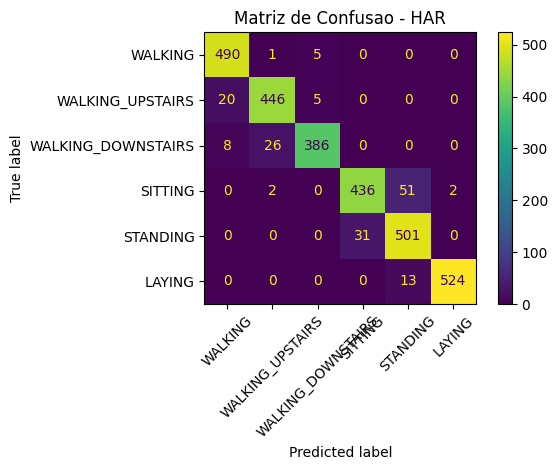

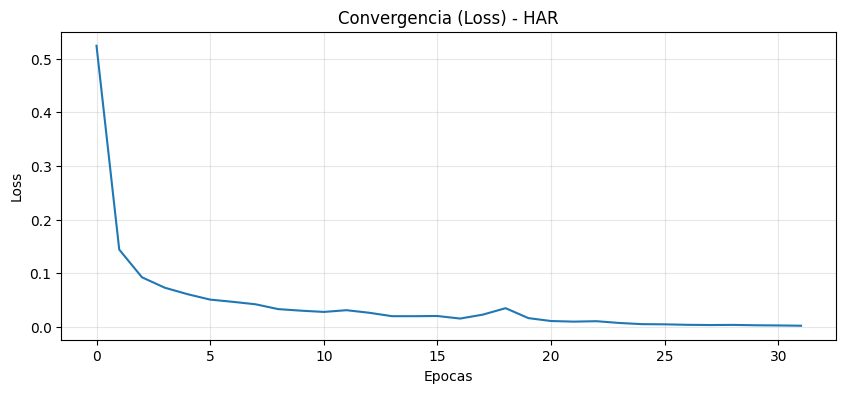

In [15]:
# Desafio 3: Human Activity Recognition with Smartphones
har_url = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
data_dir = Path("data")
zip_path = data_dir / "har.zip"
extract_dir = data_dir / "UCI HAR Dataset"

data_dir.mkdir(parents=True, exist_ok=True)

if not zip_path.exists():
    urlretrieve(har_url, zip_path)

if not extract_dir.exists():
    import zipfile

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(data_dir)

    # O pacote da UCI inclui um zip interno com os arquivos finais
    nested_zip = data_dir / "UCI HAR Dataset.zip"
    if nested_zip.exists():
        with zipfile.ZipFile(nested_zip, "r") as zf:
            zf.extractall(data_dir)

if not extract_dir.exists():
    x_train_candidates = list(data_dir.rglob("X_train.txt"))
    if not x_train_candidates:
        raise FileNotFoundError("Nao foi possivel localizar o dataset HAR apos extracao.")
    extract_dir = x_train_candidates[0].parents[1]

Xtrain_har = pd.read_csv(extract_dir / "train" / "X_train.txt", sep=r"\s+", header=None)
Xtest_har = pd.read_csv(extract_dir / "test" / "X_test.txt", sep=r"\s+", header=None)

ytrain_har = pd.read_csv(extract_dir / "train" / "y_train.txt", header=None).iloc[:, 0]
ytest_har = pd.read_csv(extract_dir / "test" / "y_test.txt", header=None).iloc[:, 0]

activity_labels = pd.read_csv(
    extract_dir / "activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["id", "label"],
)
label_map = dict(zip(activity_labels["id"], activity_labels["label"]))

# Requisito do laboratorio: LabelEncoder + StandardScaler
le = LabelEncoder()
ytrain_har_enc = le.fit_transform(ytrain_har)
ytest_har_enc = le.transform(ytest_har)
har_target_names = [label_map[int(cls)] for cls in le.classes_]

har_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(128, 64),
                max_iter=120,
                random_state=RANDOM_STATE,
                early_stopping=True,
                n_iter_no_change=10,
            ),
        ),
    ]
)
har_pipeline.fit(Xtrain_har, ytrain_har_enc)

y_pred_har = har_pipeline.predict(Xtest_har)
print("=== Human Activity Recognition ===")
print(f"Acuracia: {accuracy_score(ytest_har_enc, y_pred_har):.4f}")
print(classification_report(ytest_har_enc, y_pred_har, target_names=har_target_names))

ConfusionMatrixDisplay.from_estimator(
    har_pipeline,
    Xtest_har,
    ytest_har_enc,
    display_labels=har_target_names,
    xticks_rotation=45,
 )
plt.title("Matriz de Confusao - HAR")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(har_pipeline.named_steps["mlp"].loss_curve_)
plt.title("Convergencia (Loss) - HAR")
plt.xlabel("Epocas")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()